# Подготовка данных и моделирование

Кратко: ноутбук содержит очистку, фичеризацию и базовые модели для дневной капитализации.


In [35]:
import config.config as cfg
import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv(cfg.PROJ_ROOT)

y_name = 'dailycapitalization'
secid = ['secid']
tradedate = ['tradedate']
index = secid + tradedate
pd.set_option("display.max_columns", None)

## Подготовка данных


Чтение данных

In [36]:
dtype_dict = {
    'secid': str,
    'boardid': str,
    'primary_boardid': str,
    'shortname': str,
    'inn': str,
    # 'tradedate': str,  # parse_dates отдельно
    'year': float,
    'dailycapitalization': float,
    'close': float,
    'volume': int,
    'sector': 'category',
    'type': str,
    'issuesize': float,
    'capex_revenue_rsbu': float,
    'capex_revenue_msfo': float,
    'capital_rsbu': float,
    'capital_msfo': float,
    'current_ratio_rsbu': float,
    'current_ratio_msfo': float,
    'debt_equity_rsbu': float,
    'debt_equity_msfo': float,
    'debt_ratio_rsbu': float,
    'debt_ratio_msfo': float,
    'debtebitda_rsbu': float,
    'debtebitda_msfo': float,
    'dpr_rsbu': float,
    'dpr_msfo': float,
    'ebitda_margin_rsbu': float,
    'ebitda_margin_msfo': float,
    'ev_ebit_rsbu': float,
    'ev_ebit_msfo': float,
    'evebitda_rsbu': float,
    'evebitda_msfo': float,
    'evs_rsbu': float,
    'evs_msfo': float,
    'gross_margin_rsbu': float,
    'gross_margin_msfo': float,
    'interest_coverage_rsbu': float,
    'interest_coverage_msfo': float,
    'net_margin_rsbu': float,
    'net_margin_msfo': float,
    'net_working_capital_rsbu': float,
    'net_working_capital_msfo': float,
    'netdebt_ebitda_rsbu': float,
    'netdebt_ebitda_msfo': float,
    'operation_margin_rsbu': float,
    'operation_margin_msfo': float,
    'pbv_rsbu': float,
    'pbv_msfo': float,
    'pcf_rsbu': float,
    'pcf_msfo': float,
    'pe_rsbu': float,
    'pe_msfo': float,
    'pfcf_rsbu': float,
    'pfcf_msfo': float,
    'pffo_rsbu': float,
    'pffo_msfo': float,
    'ps_rsbu': float,
    'ps_msfo': float,
    'roa_rsbu': float,
    'roa_msfo': float,
    'roce_rsbu': float,
    'roce_msfo': float,
    'roe_rsbu': float,
    'roe_msfo': float,
    'roic_rsbu': float,
    'roic_msfo': float,
    'ros_rsbu': float,
    'ros_msfo': float,
    'line_1100': float,
    'line_1110': float,
    'line_1120': float,
    'line_1130': float,
    'line_1140': float,
    'line_1150': float,
    'line_1160': float,
    'line_1170': float,
    'line_1180': float,
    'line_1190': float,
    'line_1200': float,
    'line_1210': float,
    'line_1220': float,
    'line_1230': float,
    'line_1240': float,
    'line_1250': float,
    'line_1260': float,
    'line_1300': float,
    'line_1310': float,
    'line_1320': float,
    'line_1340': float,
    'line_1350': float,
    'line_1360': float,
    'line_1370': float,
    'line_1400': float,
    'line_1410': float,
    'line_1420': float,
    'line_1430': float,
    'line_1450': float,
    'line_1500': float,
    'line_1510': float,
    'line_1520': float,
    'line_1530': float,
    'line_1540': float,
    'line_1550': float,
    'line_1600': float,
    'line_1700': float,
    'line_2100': float,
    'line_2110': float,
    'line_2120': float,
    'line_2200': float,
    'line_2210': float,
    'line_2220': float,
    'line_2300': float,
    'line_2310': float,
    'line_2320': float,
    'line_2330': float,
    'line_2340': float,
    'line_2350': float,
    'line_2400': float,
    'line_2410': float,
    'line_2411': float,
    'line_2412': float,
    'line_2421': float,
    'line_2430': float,
    'line_2450': float,
    'line_2460': float,
    'line_2500': float,
    'line_2510': float,
    'line_2520': float,
    'line_2530': float,
    'line_2900': float,
    'line_2910': float,
    'line_3100': float,
    'line_3200': float,
    'line_3210': float,
    'line_3211': float,
    'line_3212': float,
    'line_3213': float,
    'line_3214': float,
    'line_3215': float,
    'line_3216': float,
    'line_321x': float,
    'line_3220': float,
    'line_3221': float,
    'line_3222': float,
    'line_3223': float,
    'line_3224': float,
    'line_3225': float,
    'line_3226': float,
    'line_3227': float,
    'line_322x': float,
    'line_3230': float,
    'line_3240': float,
    'line_3300': float,
    'line_3310': float,
    'line_3311': float,
    'line_3312': float,
    'line_3313': float,
    'line_3314': float,
    'line_3315': float,
    'line_3316': float,
    'line_331x': float,
    'line_3320': float,
    'line_3321': float,
    'line_3322': float,
    'line_3323': float,
    'line_3324': float,
    'line_3325': float,
    'line_3326': float,
    'line_3327': float,
    'line_332x': float,
    'line_3330': float,
    'line_3340': float,
    'line_3400': float,
    'line_3401': float,
    'line_3402': float,
    'line_3410': float,
    'line_3411': float,
    'line_3412': float,
    'line_3420': float,
    'line_3421': float,
    'line_3422': float,
    'line_3500': float,
    'line_3501': float,
    'line_3502': float,
    'line_3600': float,
    'line_4100': float,
    'line_4110': float,
    'line_4111': float,
    'line_4112': float,
    'line_4113': float,
    'line_4119': float,
    'line_411x': float,
    'line_4120': float,
    'line_4121': float,
    'line_4122': float,
    'line_4123': float,
    'line_4124': float,
    'line_4129': float,
    'line_412x': float,
    'line_4200': float,
    'line_4210': float,
    'line_4211': float,
    'line_4212': float,
    'line_4213': float,
    'line_4214': float,
    'line_4219': float,
    'line_421x': float,
    'line_4220': float,
    'line_4221': float,
    'line_4222': float,
    'line_4223': float,
    'line_4224': float,
    'line_4229': float,
    'line_422x': float,
    'line_4300': float,
    'line_4310': float,
    'line_4311': float,
    'line_4312': float,
    'line_4313': float,
    'line_4314': float,
    'line_4319': float,
    'line_431x': float,
    'line_4320': float,
    'line_4321': float,
    'line_4322': float,
    'line_4323': float,
    'line_4329': float,
    'line_432x': float,
    'line_4400': float,
    'line_4450': float,
    'line_4490': float,
    'line_4500': float,
    'line_6100': float,
    'line_6200': float,
    'line_6210': float,
    'line_6215': float,
    'line_6220': float,
    'line_6230': float,
    'line_6240': float,
    'line_6250': float,
    'line_6300': float,
    'line_6310': float,
    'line_6311': float,
    'line_6312': float,
    'line_6313': float,
    'line_6320': float,
    'line_6321': float,
    'line_6322': float,
    'line_6323': float,
    'line_6324': float,
    'line_6325': float,
    'line_6326': float,
    'line_6330': float,
    'line_6350': float,
    'line_6400': float,
    'key_rate': float,
    'inflation': float,
    'str_li_def_new': float,
    'str_li_def': float,
    'claims': float,
    'action_based_repo_fx': float,
    'action_based_secure_loans': float,
    'standing_facilities_repo_fx': float,
    'standing_facilities_secure_loans': float,
    'liabilities': float,
    'deposit_auction_based': float,
    'deposit_standing_facilities': float,
    'cbr_bonds': float,
    'net_cbr_claims': float,
    'corr_acc': float,
    'avgrr': float,
    'gold_price': float,
    'silver_price': float,
    'platinum_price': float,
    'palladium_price': float,
    'usd_price': float,
    'eur_price': float,
    'ruonia_rate': float,
    'ruonia_volume': float
}

In [37]:
df = pd.read_csv(
    cfg.PROJ_ROOT / 'data' / 'raw' / 'dataset.csv',
    parse_dates=['tradedate'],
    sep='\t',
    dtype=dtype_dict,
)
df['tradedate'] = pd.to_datetime(df['tradedate'])
df['tradeyear'] = df['tradedate'].dt.year
df.shape

(1871372, 281)

In [4]:
df['boardid'].unique()

array(['TQBR', 'TQPI', 'SMAL', 'EQDP', 'TQDE', 'EQNE', 'EQBS', 'EQLI',
       'EQNL', 'EQBR', 'EQLV', 'TQNL', 'EQDE', 'TQNE', 'TQBS', 'SPEQ',
       'EQCC', 'TQLV', 'TQDP'], dtype=object)

	•	TQBR — акции, основной стакан (T+2)
	•	TQBS — акции, T+ режим (вариация расчётов, реже используется)
	•	TQPI — режим для квалифицированных инвесторов
	•	TQDE — депозитарные расписки
	•	TQDP — DR / спецрежим
	•	TQNE — адресные сделки в T+
	•	TQLV — низколиквидные бумаги
	•	TQNL — неликвид / ограниченный режим
	•	EQBR — акции (аналог TQBR, но менее ликвидный)
	•	EQNE — адресные сделки
	•	EQBS — режим расчётов
	•	EQLI — листинг / малоликвидные
	•	EQNL — неликвид
	•	EQLV — low volume
	•	EQDE — депозитарные расписки
	•	EQDP — DR / спецрежим
	•	EQCC — клиринговый / спецрежим
	•	SMAL — неполные лоты (odd lots)
	•	SPEQ — negotiated / специальные сделки

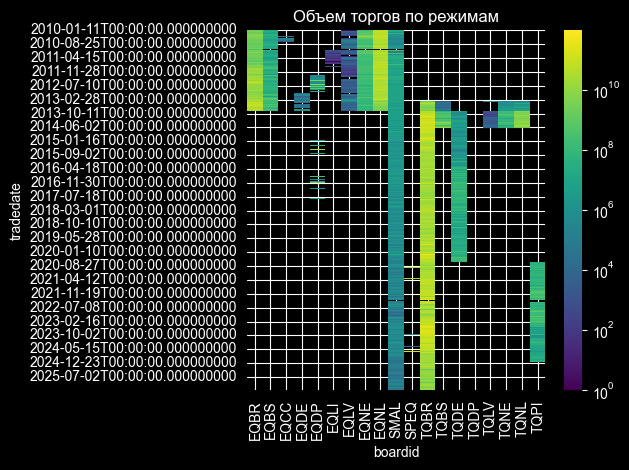

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_board_volume_heatmap(df, title):
    pivot = df.pivot_table(index='tradedate', columns='boardid', values='volume', aggfunc='sum')
    sns.heatmap(pivot, cmap="viridis", norm=LogNorm())
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_board_volume_heatmap(df, "Объем торгов по режимам")

### Заметки
- Найти все корректные ИНН (готово).
- Обработать допэмиссии.
- Собрать данные отчетности из ЦБРФ по кредитным организациям.


In [6]:
cat_cols = ['sector', 'type']
mults = [
    'capex_revenue_rsbu', 'capex_revenue_msfo', 'capital_rsbu', 'capital_msfo', 'current_ratio_rsbu', 'current_ratio_msfo', 'debt_equity_rsbu', 'debt_equity_msfo', 'debt_ratio_rsbu', 'debt_ratio_msfo', 'debtebitda_rsbu', 'debtebitda_msfo', 'dpr_rsbu', 'dpr_msfo', 'ebitda_margin_rsbu', 'ebitda_margin_msfo', 'ev_ebit_rsbu', 'ev_ebit_msfo', 'evebitda_rsbu', 'evebitda_msfo', 'evs_rsbu', 'evs_msfo', 'gross_margin_rsbu', 'gross_margin_msfo', 'interest_coverage_rsbu', 'interest_coverage_msfo', 'net_margin_rsbu', 'net_margin_msfo', 'net_working_capital_rsbu', 'net_working_capital_msfo', 'netdebt_ebitda_rsbu', 'netdebt_ebitda_msfo', 'operation_margin_rsbu', 'operation_margin_msfo', 'pbv_rsbu', 'pbv_msfo', 'pcf_rsbu', 'pcf_msfo', 'pe_rsbu', 'pe_msfo', 'pfcf_rsbu', 'pfcf_msfo', 'pffo_rsbu', 'pffo_msfo', 'ps_rsbu', 'ps_msfo', 'roa_rsbu', 'roa_msfo', 'roce_rsbu', 'roce_msfo', 'roe_rsbu', 'roe_msfo', 'roic_rsbu', 'roic_msfo', 'ros_rsbu', 'ros_msfo',
]
lines = [
    'line_1100', 'line_1110', 'line_1120', 'line_1130', 'line_1140', 'line_1150', 'line_1160', 'line_1170', 'line_1180', 'line_1190', 'line_1200', 'line_1210', 'line_1220', 'line_1230', 'line_1240', 'line_1250', 'line_1260', 'line_1300', 'line_1310', 'line_1320', 'line_1340', 'line_1350', 'line_1360', 'line_1370', 'line_1400', 'line_1410', 'line_1420', 'line_1430', 'line_1450', 'line_1500', 'line_1510', 'line_1520', 'line_1530', 'line_1540', 'line_1550', 'line_1600', 'line_1700', 'line_2100', 'line_2110', 'line_2120', 'line_2200', 'line_2210', 'line_2220', 'line_2300', 'line_2310', 'line_2320', 'line_2330', 'line_2340', 'line_2350', 'line_2400', 'line_2410', 'line_2411', 'line_2412', 'line_2421', 'line_2430', 'line_2450', 'line_2460', 'line_2500', 'line_2510', 'line_2520', 'line_2530', 'line_2900', 'line_2910', 'line_3100', 'line_3200', 'line_3210', 'line_3211', 'line_3212', 'line_3213', 'line_3214', 'line_3215', 'line_3216', 'line_321x', 'line_3220', 'line_3221', 'line_3222', 'line_3223', 'line_3224', 'line_3225', 'line_3226', 'line_3227', 'line_322x', 'line_3230', 'line_3240', 'line_3300', 'line_3310', 'line_3311', 'line_3312', 'line_3313', 'line_3314', 'line_3315', 'line_3316', 'line_331x', 'line_3320', 'line_3321', 'line_3322', 'line_3323', 'line_3324', 'line_3325', 'line_3326', 'line_3327', 'line_332x', 'line_3330', 'line_3340', 'line_3400', 'line_3401', 'line_3402', 'line_3410', 'line_3411', 'line_3412', 'line_3420', 'line_3421', 'line_3422', 'line_3500', 'line_3501', 'line_3502', 'line_3600', 'line_4100', 'line_4110', 'line_4111', 'line_4112', 'line_4113', 'line_4119', 'line_411x', 'line_4120', 'line_4121', 'line_4122', 'line_4123', 'line_4124', 'line_4129', 'line_412x', 'line_4200', 'line_4210', 'line_4211', 'line_4212', 'line_4213', 'line_4214', 'line_4219', 'line_421x', 'line_4220', 'line_4221', 'line_4222', 'line_4223', 'line_4224', 'line_4229', 'line_422x', 'line_4300', 'line_4310', 'line_4311', 'line_4312', 'line_4313', 'line_4314', 'line_4319', 'line_431x', 'line_4320', 'line_4321', 'line_4322', 'line_4323', 'line_4329', 'line_432x', 'line_4400', 'line_4450', 'line_4490', 'line_4500', 'line_6100', 'line_6200', 'line_6210', 'line_6215', 'line_6220', 'line_6230', 'line_6240', 'line_6250', 'line_6300', 'line_6310', 'line_6311', 'line_6312', 'line_6313', 'line_6320', 'line_6321', 'line_6322', 'line_6323', 'line_6324', 'line_6325', 'line_6326', 'line_6330', 'line_6350', 'line_6400',
]
macro = [
    'key_rate', 'inflation', 'str_li_def_new', 'str_li_def', 'claims', 'action_based_repo_fx', 'action_based_secure_loans', 'standing_facilities_repo_fx', 'standing_facilities_secure_loans', 'liabilities', 'deposit_auction_based', 'deposit_standing_facilities', 'cbr_bonds', 'net_cbr_claims', 'corr_acc', 'avgrr', 'gold_price', 'silver_price', 'platinum_price', 'palladium_price', 'usd_price', 'eur_price', 'ruonia_rate', 'ruonia_volume',
]

### Предобработка (sklearn pipeline)

In [ ]:
# TODO добавить сглаживание log_returns_cap
# TODO обработка secid пример АСКО
# пустой log returns
#    ACKO
#   DNKOP
#    ETLN
#   FORTP
#    GTSS
#    HIMC
#    KRKO
#    KSGR
#    KUNF
#   KUSTP
#    KZMS
#    MASZ
#    MNFD
#    NBTR
#    NPOF
#    OMZZ
#    OZON
#    RNHS
#   RNHSP
#   RODNP
#   SXPNP
#   TANLP
#    TGKO
#    TRAV
#    TRFM
#   TRUDP

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sktime.transformations.compose import ColumnEnsembleTransformer, TransformerPipeline
from sktime.transformations.series.impute import Imputer


def drop_additional_issues(df):
    mask = df['secid'].str.contains(r'-0', na=False)
    base = df.loc[mask, 'secid'].str.extract(r'^(.+?)-0')[0]
    return df[~df['secid'].isin(pd.concat([df.loc[mask, 'secid'], base]))]

def filter_boards(df):
    return df[df['boardid'].isin(['TQBR', 'EQBR', 'TQBS', 'EQBS'])].copy()

def categorize(df):
    df['type'] = df['type'].fillna('common_share').astype('category')
    df['sector'] = df['sector'].fillna('other').astype('category')
    return df

def filter_types(df):
    df = df[df['type'].isin(['common_share', 'preferred_share'])]
    return df

def replace_zeros_with_nan(df):
    return df.replace(0, np.nan)

def gather_secids(df):
    df['inn'] = df['inn'].str.zfill(10)
    def canonical_secid(group):
        # минимальная длина
        min_len = group['secid'].str.len().min()
        candidates = group[group['secid'].str.len() == min_len]
        # если несколько кандидатов — берём первый по tradedate
        return candidates['secid'].iloc[0]

    df_common = df[df['type'] == 'common_share']
    df_preferred = df[df['type'] == 'preferred_share']
    inn_to_secid = df_common.groupby('inn').apply(canonical_secid).to_dict()
    df_common['secid'] = df_common['inn'].map(inn_to_secid)
    inn_to_secid = df_preferred.groupby('inn').apply(canonical_secid).to_dict()
    df_preferred['secid'] = df_preferred['inn'].map(inn_to_secid)
    df = pd.concat([df_common, df_preferred], ignore_index=True)
    return df

def set_index(df):
    return df.sort_values(['secid', 'tradedate', 'volume', y_name], ascending=[True, True, False, False]).groupby(index).first()

def fill_days(df):
    return (
        df
        .groupby(level="secid")
        .apply(lambda x: x.droplevel(0).asfreq("D"))
    ).ffill()

def final_target_imputer(df):
    outstanding_shares = df[y_name] / df['close']
    mask = df[y_name].isna() & df['close'].notna() & outstanding_shares.notna()
    df.loc[mask, y_name] = df.loc[mask, 'close'] * outstanding_shares
    return df

def filter_zero_target(df):
    return df[df[y_name] > 1e-6]

def filter_years(df):
    return df[df['year'].notna()]

def add_log_returns(df: pd.DataFrame, col: str, lags: list[int]) -> pd.DataFrame:
    df = df.copy()

    # проверка MultiIndex
    if not isinstance(df.index, pd.MultiIndex):
        raise ValueError("DataFrame must have MultiIndex with levels ['secid', 'tradedate']")

    for lag in lags:
        col_name = f"log_returns_{col}_{lag}"
        # transform сохраняет индекс без добавления уровней
        df[col_name] = df.groupby(level='secid')[col].transform(
            lambda x: np.sign(x) * np.log(np.abs(x)).diff(lag)
        )

    return df

# def add_windows(df: pd.DataFrame, col: str, windows: list[int]) -> pd.DataFrame:
#     """
#     Create rolling window features and returns for specified columns and window sizes.
#     """
#     for window in windows:
#         df[f'rolling_mean_{col}_{window}'] = df[col].shift(1).rolling(window).mean()
#         df[f'log_returns_rolling_mean_{col}_{window}'] = np.log(df[col] / df[f'rolling_mean_{col}_{window}'])
#     return df

def replace_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    """
    col = f'log_returns_{y_name}_1'
    df.loc[df[col] == 0, col] = df.loc[df[col] == 0, 'log_returns_close_1']
    return df

prep_df = Pipeline([
    ('drop_additional_issues', FunctionTransformer(drop_additional_issues, validate=False)),
    ('filter_boards', FunctionTransformer(filter_boards, validate=False)),
    ('categorize', FunctionTransformer(categorize, validate=False)),
    ('filter_types', FunctionTransformer(filter_types, validate=False)),
    ('replace_zeros_with_nan', FunctionTransformer(replace_zeros_with_nan, validate=False)),
    ('gather_secids', FunctionTransformer(gather_secids, validate=False)),
    ('set_index', FunctionTransformer(set_index, validate=False)),
    ('fill_days', FunctionTransformer(fill_days, validate=False)),
    ("impute", ColumnEnsembleTransformer(
        transformers=[
            ("macro_imputer", TransformerPipeline([
                Imputer(method="ffill"),
                Imputer(method="bfill"),
            ]), macro),
            ("volume_imputer", Imputer(method="drift"), ['volume']),
            ("target_imputer", Imputer(method="drift"), [y_name]),
            ("close_imputer", Imputer(method="drift"), ['close']),
        ],
        remainder="passthrough",
        )
    ),
    ('final_target_imputer', FunctionTransformer(final_target_imputer, validate=False)),
    ('filter_zero_target', FunctionTransformer(filter_zero_target, validate=False)),
    ('add_log_returns_cap', FunctionTransformer(add_log_returns, kw_args={'col': y_name, 'lags': [1, 5, 10, 20, 60, 120, 365]}, validate=False)),
    # ('add_windows_cap', FunctionTransformer(add_windows, kw_args={'col': y_name, 'windows': [5, 10, 20, 60, 120, 365]}, validate=False)),
    ('add_log_returns_close', FunctionTransformer(add_log_returns, kw_args={'col': 'close', 'lags': [1, 5, 10, 20, 60, 120, 365]}, validate=False)),
    # ('add_windows_close', FunctionTransformer(add_windows, kw_args={'col': 'close', 'windows': [5, 10, 20, 60, 120, 365]}, validate=False)),
    ('add_log_returns_volume', FunctionTransformer(add_log_returns, kw_args={'col': 'volume', 'lags': [1]}, validate=False)),
    ('replace_returns', FunctionTransformer(replace_returns, validate=False)),
    ('filter_years', FunctionTransformer(filter_years, validate=False)),
])

df = prep_df.fit_transform(df)
df.shape

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_1563/3460127468.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inn_to_secid = df_common.groupby('inn').apply(canonical_secid).to_dict()
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_1563/3460127468.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_common['secid'] = df_common['inn'].map(inn_to_secid)
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_1563/3460127468.py:41:

(924522, 318)

### Сглаживание

Smoothing annual reports data

In [11]:
from src.steps.smoothing import lowess_smooth

new_cols = {}
for col in mults + lines:
    new_col = 'smoothed_' + col
    new_cols[new_col] = lowess_smooth(df[col])
    print(new_col)
df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

smoothed_capex_revenue_rsbu
smoothed_capex_revenue_msfo
smoothed_capital_rsbu
smoothed_capital_msfo
smoothed_current_ratio_rsbu
smoothed_current_ratio_msfo
smoothed_debt_equity_rsbu
smoothed_debt_equity_msfo
smoothed_debt_ratio_rsbu
smoothed_debt_ratio_msfo
smoothed_debtebitda_rsbu
smoothed_debtebitda_msfo
smoothed_dpr_rsbu
smoothed_dpr_msfo
smoothed_ebitda_margin_rsbu
smoothed_ebitda_margin_msfo
smoothed_ev_ebit_rsbu
smoothed_ev_ebit_msfo
smoothed_evebitda_rsbu
smoothed_evebitda_msfo
smoothed_evs_rsbu
smoothed_evs_msfo
smoothed_gross_margin_rsbu
smoothed_gross_margin_msfo
smoothed_interest_coverage_rsbu
smoothed_interest_coverage_msfo
smoothed_net_margin_rsbu
smoothed_net_margin_msfo
smoothed_net_working_capital_rsbu
smoothed_net_working_capital_msfo
smoothed_netdebt_ebitda_rsbu
smoothed_netdebt_ebitda_msfo
smoothed_operation_margin_rsbu
smoothed_operation_margin_msfo
smoothed_pbv_rsbu
smoothed_pbv_msfo
smoothed_pcf_rsbu
smoothed_pcf_msfo
smoothed_pe_rsbu
smoothed_pe_msfo
smoothed_pfc

/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


smoothed_capex_revenue_rsbu


/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


smoothed_capex_revenue_msfo


...

/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


smoothed_line_6350


/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


smoothed_line_6400


(924522, 804)

In [ ]:
new_cols = {}
for col in mults + lines:
    new_col = 'smoothed_' + col
    df = add_log_returns(df, new_col, [1])
    print(new_col)
# df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
df.shape

In [56]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

desc = df[[col for col in df.columns if col.startswith('smoothed_')]].describe(include='all')
cols_minmax = desc.loc['min'][desc.loc['min'] > -1e-6].index.tolist()
cols_standard = desc.loc['min'][desc.loc['min'] < -1e-6].index.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('mm', MinMaxScaler(), cols_minmax),
        ('st', StandardScaler(), cols_standard),
    ],
)
df_sc = preprocess.fit_transform(df)
df[preprocess.get_feature_names_out()] = df_sc
df.shape

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_1563/3747949882.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[preprocess.get_feature_names_out()] = df_sc
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_1563/3747949882.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[preprocess.get_feature_names_out()] = df_sc
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_1563/3747949882.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

(924522, 1060)

Save smoothed data

In [57]:
df.to_csv(
    cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset_smoothed.csv',
    sep='\t',
)

## ЧЕРНОВИК sktime TimeSeriesForestRegressor и Feature Selection

In [1]:
import config.config as cfg
import pandas as pd
import numpy as np

y_name = 'log_returns_dailycapitalization_1'
secid = ['secid']
tradedate = ['tradedate']
index = secid + tradedate
pd.set_option("display.max_columns", None)

df = pd.read_csv(
    cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset_smoothed.csv',
    nrows=1,
    # dtype=dtype_dict,
    sep='\t',
    # usecols=list(dtype_dict.keys()),
)
dtype_dict = {
    'secid': str,
    'tradedate': str,  # parse_dates отдельно
    'dailycapitalization': float,
    'log_returns_dailycapitalization_1': float,
    'log_returns_dailycapitalization_5': float,
    **{col: 'float' for col in df.columns if col.startswith('log_returns_smoothed_')},
    **{col: 'float' for col in df.columns if col.startswith('cat__')},
    **{col: 'float' for col in df.columns if col.startswith('mm__')},
    **{col: 'float' for col in df.columns if col.startswith('st__')},
}

2026-04-03 11:29:49.327 | INFO     | config.config:<module>:11 - PROJ_ROOT path is: /Users/alexander/PycharmProjects/vmk_thesis


In [7]:
import config.config as cfg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

y_name = 'log_returns_smoothed_dailycapitalization_1'
secid = ['secid']
tradedate = ['tradedate']
index = secid + tradedate
pd.set_option("display.max_columns", None)

df = pd.read_csv(
    cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset_smoothed.csv',
    dtype=dtype_dict,
    sep='\t',
    usecols=list(dtype_dict.keys()),
)
df['tradedate'] = pd.to_datetime(df['tradedate'])
df = df[df[y_name].notna()]
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
df = df.sort_values(index).set_index(index)
df.shape

(888413, 503)

In [16]:
rows_per_secid = df.groupby(level="secid").size().reset_index().sort_values(0)
df = df[df.index.get_level_values('secid').isin(rows_per_secid[rows_per_secid[0] > 60]['secid'])]

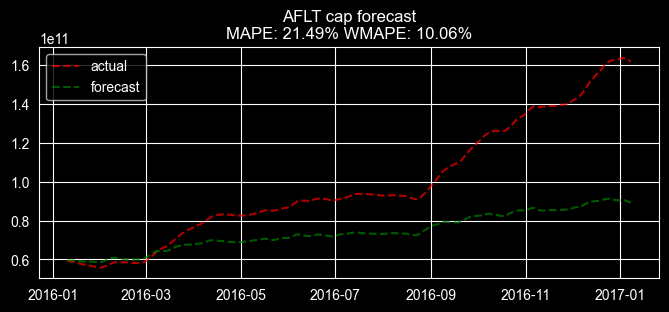

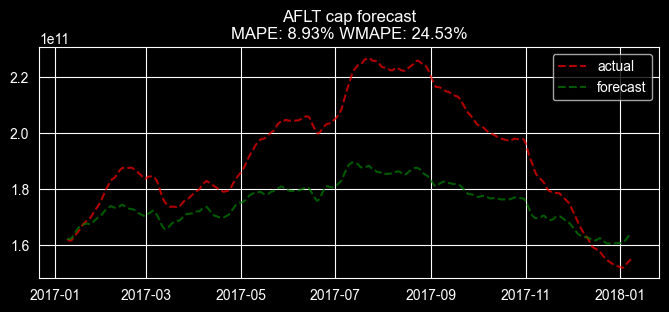

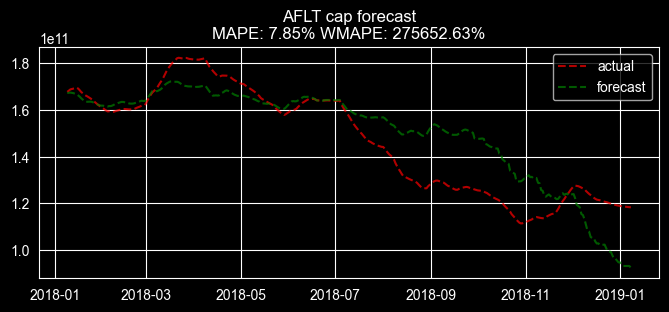

In [ ]:
from src.utils import restore_cap
from src.evaluate import mape_by_secid, wmape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import split_multiindex_by_date

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.compose import YfromX
from sktime.split import ExpandingWindowSplitter
from sklearn.ensemble import GradientBoostingRegressor

y, X = df[y_name].to_frame("log_return"), df.drop(columns=[y_name, "log_returns_dailycapitalization_1"])

reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
forecaster = YfromX(estimator=reg, pooling="global")

n = 365
fh = np.arange(1, n + 1)
cv = ExpandingWindowSplitter(initial_window=n * 5, step_length=n, fh=fh)

scores = []

for fold, (train_idx, test_idx) in enumerate(split_multiindex_by_date(y, cv)):
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    common_idx = y_test.index.intersection(X_test.index)
    y_test = y_test.loc[common_idx]
    X_test = X_test.loc[common_idx]

    X_train_m = X_train.drop(columns=["dailycapitalization"])
    X_test_m = X_test.drop(columns=["dailycapitalization"])

    test_dates = y_test.index.get_level_values("tradedate").unique().sort_values()
    needed_dates = set(test_dates)

    secid_ok = (
        X_test_m.reset_index()
        .groupby("secid")["tradedate"]
        .apply(lambda s: set(s) >= needed_dates)
    )
    secids_keep = secid_ok[secid_ok].index

    y_test = y_test.loc[pd.IndexSlice[secids_keep, :]]
    X_test_m = X_test_m.loc[pd.IndexSlice[secids_keep, :]]

    y_train = y_train.loc[pd.IndexSlice[secids_keep, :]]
    X_train_m = X_train_m.loc[pd.IndexSlice[secids_keep, :]]

    cap0 = X_test.loc[pd.IndexSlice[secids_keep, :], "dailycapitalization"].groupby(level="secid").first()

    fh_rel = ForecastingHorizon(np.arange(1, len(test_dates) + 1), is_relative=True, freq="D")

    forecaster.fit(y_train, X_train_m)
    y_pred = forecaster.predict(fh=fh_rel, X=X_test_m)

    cap_y_test = restore_cap(y_test.iloc[:, 0], cap0)
    cap_y_pred = restore_cap(y_pred.iloc[:, 0], cap0)

    mape_secid = mape_by_secid(cap_y_test, cap_y_pred)
    score = wmape(cap_y_test, cap_y_pred, weights=cap_y_test)
    scores.append(score)

    ticker = "AFLT"
    plt.figure(figsize=(8, 3))
    plt.title(f"{ticker} cap forecast\nMAPE: {mape_secid[ticker]*100:.2f}% WMAPE: {score*100:.2f}%")
    plt.plot(cap_y_test.xs(ticker, level="secid"), "r--", alpha=0.7)
    plt.plot(cap_y_pred.xs(ticker, level="secid"), "g--", alpha=0.7)
    plt.legend(["actual", "forecast"])
    plt.show()

np.mean(scores), np.std(scores)

In [ ]:
from src.features import get_feature_importances

feature_importances: pd.Series = get_feature_importances(forecaster)
feature_importances

In [110]:
import numpy as np
import pandas as pd
import yfinance as yf

from sktime.forecasting.compose import make_reduction
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.base import ForecastingHorizon
from sktime.regression.interval_based import TimeSeriesForestRegressor

from ngboost import NGBoost
from ngboost.distns import Normal
from ngboost.scores import LogScore

# ---------- 1) Данные: цена акции ----------
ticker = "MSFT"
df = yf.download(ticker, start="2018-01-01", auto_adjust=True, progress=False)

# целевая
y = df["Close"].asfreq("B").ffill()
y.name = "close"

In [112]:
# ---------- 2) Модель 1: TimeSeriesForestRegressor ----------
tsfr = TimeSeriesForestRegressor(
    n_estimators=200,
    random_state=42,
)

fc_tsfr = make_reduction(
    tsfr,
    strategy="recursive",
    window_length=24,
)

fc_tsfr.fit(y_train)
y_pred_tsfr = fc_tsfr.predict(fh, )

print("TSFR forecast:")
print(y_pred_tsfr.head())


/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future ve

TSFR forecast:
Ticker            MSFT
Date                  
2026-02-17  405.278528
2026-02-18  405.448073
2026-02-19  407.243692
2026-02-20  408.591440
2026-02-23  408.951109


/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)


In [113]:

# ---------- 3) Модель 2: NGBoost ----------
ngb = NGBoost(
    Dist=Normal,
    Score=LogScore,
    n_estimators=500,
    learning_rate=0.01,
    random_state=0,
)

fc_ngb = make_reduction(
    ngb,
    strategy="recursive",
    window_length=24,
)

fc_ngb.fit(y_train)
y_pred_ngb = fc_ngb.predict(fh)

print("NGBoost forecast:")
print(y_pred_ngb.head())

[iter 0] loss=6.2545 val_loss=0.0000 scale=2.0000 norm=212.3623
[iter 100] loss=5.0572 val_loss=0.0000 scale=2.0000 norm=29.7455
[iter 200] loss=4.0831 val_loss=0.0000 scale=2.0000 norm=7.2639
[iter 300] loss=3.2338 val_loss=0.0000 scale=2.0000 norm=5.4790
[iter 400] loss=2.7205 val_loss=0.0000 scale=2.0000 norm=5.2657


/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future ve

NGBoost forecast:
Ticker            MSFT
Date                  
2026-02-17  400.721399
2026-02-18  399.105878
2026-02-19  396.942760
2026-02-20  396.272777
2026-02-23  394.578065


/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sktime/forecasting/base/_fh.py:946: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return x.to_period(freq)


•
DirectTabularRegressionForecaster
•
RecursiveTabularRegressionForecaster
•
MultioutputTabularRegressionForecaster
•
DirRecTabularRegressionForecaster
•
DirectTimeSeriesRegressionForecaster
•
RecursiveTimeSeriesRegressionForecaster
•
MultioutputTimeSeriesRegressionForecaster
•
DirRecTimeSeriesRegressionForecaster
•
DirectReductionForecaster
•
RecursiveReductionForecaster

In [ ]:
from sktime.forecasting.arima import ARIMA

forecaster = ARIMA()

y_pred = forecaster.fit(y, fh=[1, 2]).predict()

In [ ]:
import pandas as pd
import numpy as np
import config.config as cfg
pd.set_option("display.max_columns", None)

https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.regression.interval_based.TimeSeriesForestRegressor.html

	•	Подходит для табличной регрессии временных рядов, когда важно быстрое обучение и интерпретируемость.
	•	Не требует стационарности ряда.